In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
train_df = pd.read_csv('data/archive/fashion-mnist_train.csv')
test_df = pd.read_csv('data/archive/fashion-mnist_test.csv')

In [5]:
# small_df, _ = train_test_split(
#     train_df,
#     train_size=20000,
#     stratify=train_df['label'],
#     random_state=42
# )

# train_small, val_small = train_test_split(
#     small_df,
#     test_size=0.2,
#     stratify=small_df['label'],
#     random_state=42
# )

# _, test_small = train_test_split(
#     test_df,
#     test_size=4000,
#     stratify=test_df['label'],
#     random_state=42
# )

# train_small.shape, val_small.shape, test_small.shape

In [6]:
train_df, val_small = train_test_split(
    train_df,
    test_size=10000,
    stratify=train_df['label'],
    random_state=42
)
train_df.shape, val_small.shape, test_df.shape

((50000, 785), (10000, 785), (10000, 785))

In [7]:
print(train_df.head())
print(train_df['label'].value_counts())
print(train_df.describe())
print(train_df.info())
print(train_df.isna().sum())

       label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
4938       9       0       0       0       0       0       0       0       0   
55215      9       0       0       0       0       0       0       0       0   
54752      0       0       0       0       0       0       0       0       0   
58939      7       0       0       0       0       0       0       0       0   
51752      9       0       0       0       0       0       0       0       0   

       pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  \
4938        0  ...         0         0         0         0         0   
55215       0  ...         0         0         0         0         0   
54752       9  ...        71        31         0         0         0   
58939       0  ...         0         0         0         0         0   
51752       0  ...         0         0         0         0         0   

       pixel780  pixel781  pixel782  pixel783  pixel784  
4938          0         0   

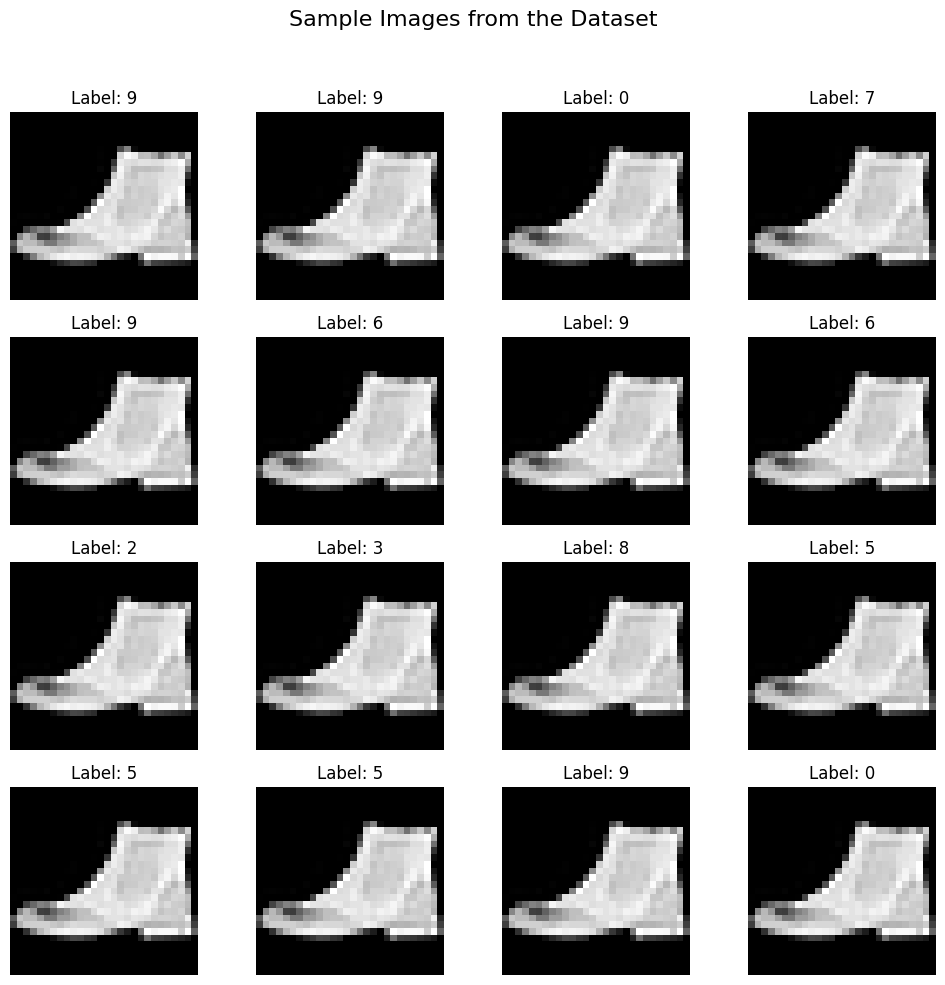

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Sample Images from the Dataset', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    image = train_df.iloc[0, 1:].values.reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {train_df.iloc[i, 0]}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [11]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_val = val_small.iloc[:, 1:].values
y_val = val_small.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [12]:
print(X_train.shape)  # (5000, 784)
print(y_train.shape)  # (5000,)
print(X_test.shape)   # (1000, 784)
print(y_test.shape)   # (1000,)


(50000, 784)
(50000,)
(10000, 784)
(10000,)


In [14]:
X_train = train_df.iloc[:, 1:].to_numpy(dtype="float32") / 255.0
X_val = val_small.iloc[:, 1:].to_numpy(dtype="float32") / 255.0
X_test = test_df.iloc[:, 1:].to_numpy(dtype="float32") / 255.0

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0) + 1e-7

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

In [15]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [16]:
train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)
test_dataset = CustomDataset(X_test, y_test)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=True
)

In [18]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
            # nn.softmax()   #no need to define explicitly automatically present
        )

        self.apply(self.__init__weights)

    def __init__weights(self, layer):
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.model(x)
    

In [19]:
# Instantiate the model
epochs = 100
learning_rate = 1e-3  # 1x10 ** -3 ==> 0.001

In [20]:
from torch.optim.lr_scheduler import StepLR

# Instantiate the model
model = MyNN(X_train.shape[1])
model = model.to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

In [21]:
best_val_loss = float("inf")
best_state = None
patience = 5
patience_counter = 0

for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:

        # Move data to the appropriate device
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        #forward pass
        outputs = model(batch_features)

        #compute the loss
        loss = criterion(outputs, batch_labels)

        #backward pass
        optimizer.zero_grad()
        loss.backward()

        #update gradients and weights
        optimizer.step()
        total_epoch_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_features, batch_labels in val_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    scheduler.step()  # update LR once per epoch
    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Train Loss: {total_epoch_loss/len(train_loader):.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"LR: {scheduler.get_last_lr()[0]:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1/100, Train Loss: 0.6380, Val Loss: 0.4056, LR: 0.001000
Epoch 2/100, Train Loss: 0.4123, Val Loss: 0.3546, LR: 0.001000
Epoch 3/100, Train Loss: 0.3647, Val Loss: 0.3271, LR: 0.001000
Epoch 4/100, Train Loss: 0.3270, Val Loss: 0.3446, LR: 0.001000
Epoch 5/100, Train Loss: 0.3031, Val Loss: 0.3212, LR: 0.001000
Epoch 6/100, Train Loss: 0.2885, Val Loss: 0.3193, LR: 0.001000
Epoch 7/100, Train Loss: 0.2692, Val Loss: 0.3134, LR: 0.001000
Epoch 8/100, Train Loss: 0.2577, Val Loss: 0.3094, LR: 0.001000
Epoch 9/100, Train Loss: 0.2412, Val Loss: 0.3102, LR: 0.001000
Epoch 10/100, Train Loss: 0.2288, Val Loss: 0.3051, LR: 0.000500
Epoch 11/100, Train Loss: 0.1959, Val Loss: 0.3010, LR: 0.000500
Epoch 12/100, Train Loss: 0.1827, Val Loss: 0.3017, LR: 0.000500
Epoch 13/100, Train Loss: 0.1736, Val Loss: 0.3100, LR: 0.000500
Epoch 14/100, Train Loss: 0.1709, Val Loss: 0.3171, LR: 0.000500
Epoch 15/100, Train Loss: 0.1606, Val Loss: 0.3158, LR: 0.000500
Epoch 16/100, Train Loss: 0.1565, 

In [22]:
# set model to evaluation mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [31]:
#evaluate the model on the test set
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # Move data to the appropriate device
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

#evaluate the model on the test set
total1 = 0
correct1 = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        # Move data to the appropriate device
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total1 += batch_labels.size(0)
        correct1 += (predicted == batch_labels).sum().item()


print(test := f"Accuracy of the model on the test set: {100 * correct / total}%")
print(train := f"Accuracy of the model on the training set: {100 * correct1 / total1}%")

print('the difference is ', abs(float(test.split(': ')[1][:-1]) - float(train.split(': ')[1][:-1])), '%')
print('no sign of overfitting, the model is generalizing well to unseen data')

Accuracy of the model on the test set: 89.95%
Accuracy of the model on the training set: 94.846%
the difference is  4.896000000000001 %
no sign of overfitting, the model is generalizing well to unseen data
